In [1]:
import matplotlib.pyplot as plt
import numpy as np

from firm3d.plotting.plotting_helpers import plot_trajectory_poloidal

In [ ]:
nParticles = 5000
# Critical angle for barely trapped particle classification
barely_trapped_crit = 2 * np.pi * 1.25
# Critical value of dchi/dchi_predicted for ripple trapped
ripple_trapped_crit = 0.5

trapped_bool = []  # True if particle mirrors at least once
barely_trapped_frac = []  # Fraction barely trapped (dchis > 2*pi)
ripple_trapped_frac = []  # Fraction ripple trapped
banana_frac = []  # Fraction banana trapped (in main well)
Jpar_var = []  # Variation in Jpar (nbounce > 3, otherwise 0)
nbounces = []  # Number of mirror points
gammac_mean = []  # Mean Gammac (nbounce > 1, otherwise 0)
indices = []  # Particle indices for those lost to the wall
timelost = []  # Time lost to the wall for particles that were lost
ntransitions = []  # Number of transitions between trapped states
for iParticle in range(nParticles):
    try:
        # Load particle data (only saved if lost to wall)
        dict = np.load(f"particle_{iParticle}.npz")
    except FileNotFoundError:
        continue

    trapped_bool.append(dict["nbounce"] > 0)
    barely_trapped_frac.append(dict["barely_trapped_frac"])
    ripple_trapped_frac.append(dict["ripple_trapped_frac"])
    banana_frac.append(dict["banana_frac"])
    Jpar_var.append(dict["Jpar_var"])
    nbounces.append(dict["nbounce"])
    gammac_mean.append(dict["gammac_mean"])
    indices.append(iParticle)
    timelost.append(dict["losttime"])
    ntransitions.append(dict["ntransitions"])

trapped_bool = np.array(trapped_bool)
barely_trapped_frac = np.array(barely_trapped_frac)
ripple_trapped_frac = np.array(ripple_trapped_frac)
banana_frac = np.array(banana_frac)
Jpar_var = np.array(Jpar_var)
nbounces = np.array(nbounces)
gammac_mean = np.array(gammac_mean)
indices = np.array(indices)
timelost = np.array(timelost)
ntransitions = np.array(ntransitions)

print(f"Number of trapped particles: {np.count_nonzero(trapped_bool)}")
print(f"Number of passing particles: {np.count_nonzero(trapped_bool == 0)}")
print(f"Number of barely trapped particles: {np.count_nonzero(barely_trapped_frac)}")
print(f"Number of ripple trapped particles: {np.count_nonzero(ripple_trapped_frac)}")
print(f"Number of pure banana particles: {np.count_nonzero(banana_frac == 1)}")

Number of trapped particles: 551
Number of passing particles: 0
Number of barely trapped particles: 115
Number of ripple trapped particles: 430
Number of pure banana particles: 110


Text(0.5, 1.0, 'Normalized variation in Jpar for pure "banana" particles')

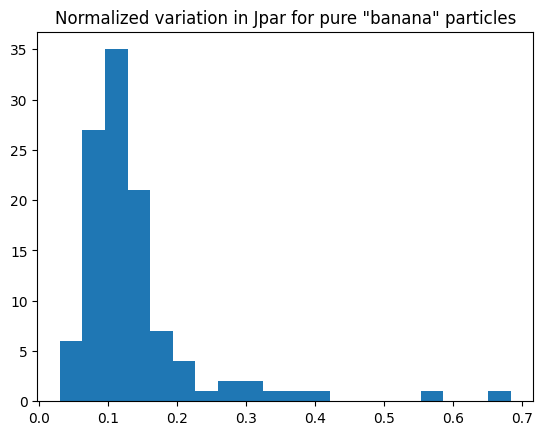

In [3]:
# Only look at chaos in particles trapped in main well
plt.figure()
plt.hist(Jpar_var[(banana_frac == 1) * (Jpar_var != 0)], bins=20)
plt.title('Normalized variation in Jpar for pure "banana" particles')

Text(0.5, 1.0, 'Gammac for pure "banana" particles')

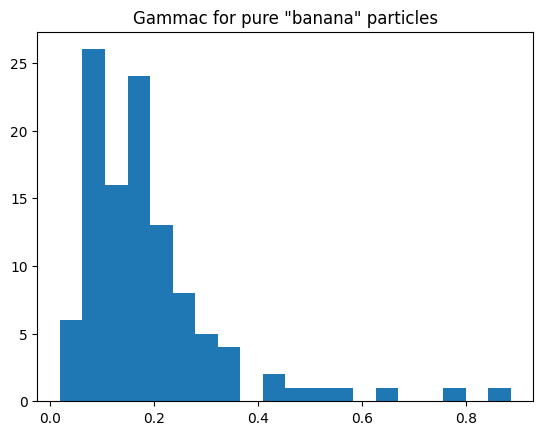

In [4]:
# Look at measure of drift convection
plt.figure()
plt.hist(gammac_mean[(banana_frac == 1) * (gammac_mean != 0)], bins=20)
plt.title('Gammac for pure "banana" particles')

(array([65., 46., 50., 47., 41., 38., 41., 32., 34., 29., 20., 22., 16.,
        21., 18.,  8.,  6.,  8.,  4.,  5.]),
 array([  1. ,  34.2,  67.4, 100.6, 133.8, 167. , 200.2, 233.4, 266.6,
        299.8, 333. , 366.2, 399.4, 432.6, 465.8, 499. , 532.2, 565.4,
        598.6, 631.8, 665. ]),
 <BarContainer object of 20 artists>)

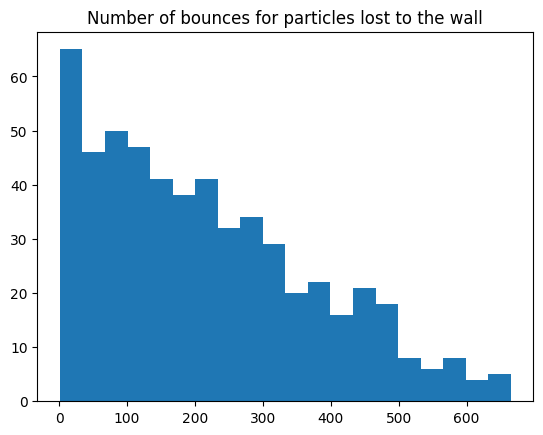

In [5]:
plt.figure()
plt.title("Number of bounces for particles lost to the wall")
plt.hist(nbounces, bins=20)

(array([71., 43., 44., 44., 43., 18., 23., 43., 20., 19., 16., 24., 25.,
        14., 18., 18., 26.,  9., 20., 13.]),
 array([9.88488192e-06, 5.08514675e-04, 1.00714447e-03, 1.50577426e-03,
        2.00440405e-03, 2.50303385e-03, 3.00166364e-03, 3.50029343e-03,
        3.99892322e-03, 4.49755302e-03, 4.99618281e-03, 5.49481260e-03,
        5.99344239e-03, 6.49207219e-03, 6.99070198e-03, 7.48933177e-03,
        7.98796157e-03, 8.48659136e-03, 8.98522115e-03, 9.48385094e-03,
        9.98248074e-03]),
 <BarContainer object of 20 artists>)

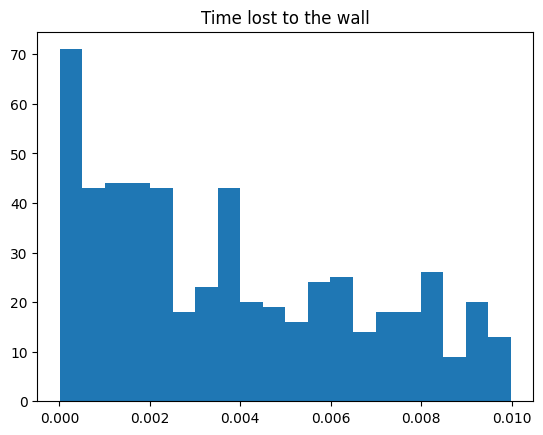

In [6]:
plt.figure()
plt.title("Time lost to the wall")
plt.hist(timelost, bins=20)

Text(0.5, 1.0, 'Number of transitions between trapped states for particles that mirror more than once')

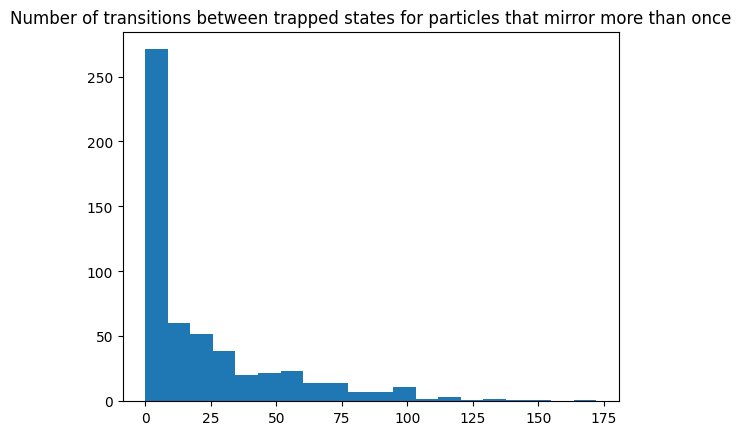

In [ ]:
plt.figure()
plt.hist(ntransitions, bins=20)
plt.title("Number of transitions between trapped states")

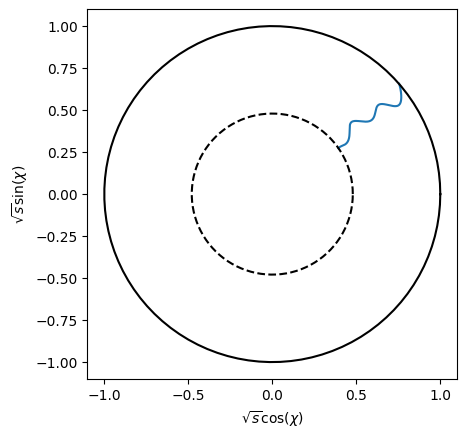

In [8]:
# Plot an example ripple trapped particle trajectory
ripple_indices = indices[np.where(ripple_trapped_frac == 1)]
index = ripple_indices[0]
res_ty = np.loadtxt(f"particle_{index}_traj.txt")

ax = plot_trajectory_poloidal(res_ty, helicity_M=1, helicity_N=0)

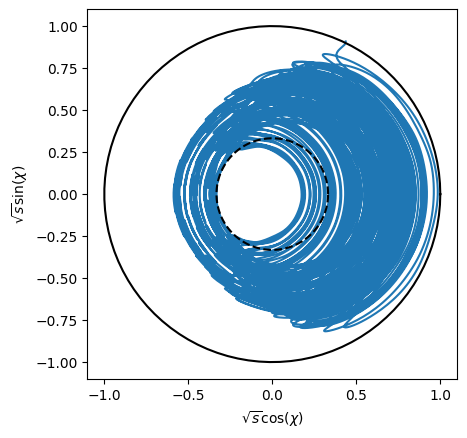

In [9]:
# Plot an example transitioning particle trajectory
transition_indices = indices[np.where(ntransitions > 50)]
index = transition_indices[0]
res_ty = np.loadtxt(f"particle_{index}_traj.txt")

ax = plot_trajectory_poloidal(res_ty, helicity_M=1, helicity_N=0)

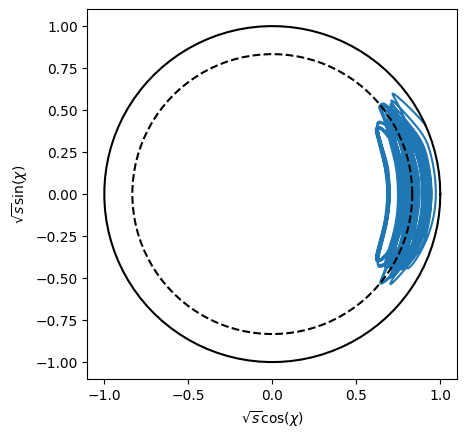

In [10]:
# Plot an example drift-convective banana particle trajectory
convective_indices = indices[np.where((banana_frac == 1) * (gammac_mean > 0.4))]
index = convective_indices[0]
res_ty = np.loadtxt(f"particle_{index}_traj.txt")

ax = plot_trajectory_poloidal(res_ty, helicity_M=1, helicity_N=0)

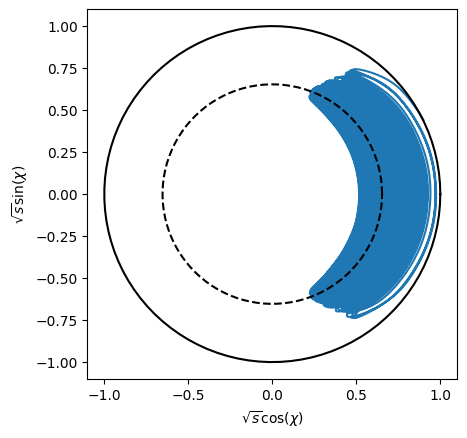

In [11]:
# Plot an example chaotic banana particle trajectory
chaotic_indices = indices[np.where((banana_frac == 1) * (Jpar_var > 0.1))]
index = chaotic_indices[0]
res_ty = np.loadtxt(f"particle_{index}_traj.txt")

ax = plot_trajectory_poloidal(res_ty, helicity_M=1, helicity_N=0)